# ACF and `seq_len` recommendation

Single artifact for ACF / input window (Informer2020, AirFormer, GAT-Informer).

1. Set `ZONE` and `CONTAMINANT`.
2. Ejecuta todas las celdas.
3. At the end you get the **recommended `seq_len`** (also saved as JSON).

Output: `analysis/acf/zone_<n>/<CONT>/`

In [4]:
# ===== CONFIG =====
ZONE = 2
CONTAMINANT = "PM10"  # NO2, SO2, PM10, CO, O3, NO, PM25, NOx
START_DATE = "2019-01-01"
HORIZON = 24
MAX_LAG = 168
ACF_THRESHOLD = 0.3
MIN_SEQ_LEN = 24
SEQ_LEN_CANDIDATES = [12, 24, 48, 72, 96, 168]

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Raiz del repo: subir directorios hasta encontrar data/training
ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data" / "training").is_dir():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "No se encontro data/training/. "
        "Abre el notebook desde el repo MASTER o cambia el cwd del kernel."
    )

DATASET_PATH = ROOT / f"data/training/zone_{ZONE}/dataset_zone_{ZONE}_{CONTAMINANT}.csv"
OUTPUT_DIR = ROOT / f"analysis/acf/zone_{ZONE}/{CONTAMINANT}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No existe el dataset:\n  {DATASET_PATH}\n"
        f"Genera antes el CSV definitivo de zona {ZONE} / {CONTAMINANT}."
    )

print(f"Zona        : {ZONE}")
print(f"Contaminante: {CONTAMINANT}")
print(f"ROOT        : {ROOT}")
print(f"Dataset     : {DATASET_PATH.relative_to(ROOT)}")
print(f"Salida      : {OUTPUT_DIR.relative_to(ROOT)}")
print(f"Existe CSV  : {DATASET_PATH.exists()}")


Zona        : 2
Contaminante: PM10
ROOT        : C:\Users\105116\MASTER
Dataset     : data\training\zone_2\dataset_zone_2_PM10.csv
Salida      : analysis\acf\zone_2\PM10
Existe CSV  : True


## 1. Funciones ACF / seq_len

In [5]:
def load_series_by_station(path, target_col, start_date):
    df = pd.read_csv(
        path,
        parse_dates=["time"],
        usecols=["time", "station_name", target_col],
        low_memory=False,
    )
    start = pd.Timestamp(start_date)
    df = df[df["time"] >= start].copy()
    if df.empty:
        raise ValueError(f"No hay datos desde {start_date}")

    series_by_station = {}
    for station_name, group in df.groupby("station_name", sort=True):
        values = (
            group.sort_values("time")[target_col]
            .dropna()
            .to_numpy(dtype=np.float64)
        )
        if len(values) > 1:
            series_by_station[station_name] = values
    if not series_by_station:
        raise ValueError(f"No valid series for {target_col}")
    return series_by_station


def compute_acf(series, max_lag):
    centered = series - series.mean()
    acf = np.ones(max_lag + 1, dtype=np.float64)
    for lag in range(1, max_lag + 1):
        if lag >= len(centered):
            acf[lag:] = np.nan
            break
        acf[lag] = np.corrcoef(centered[:-lag], centered[lag:])[0, 1]
    return acf


def first_lag_below(acf, threshold):
    for lag in range(1, len(acf)):
        if np.isnan(acf[lag]):
            break
        if acf[lag] < threshold:
            return lag
    return None


def round_up_to_candidate(value, candidates):
    for candidate in candidates:
        if candidate >= value:
            return candidate
    return candidates[-1]


def recommend_seq_len(median_acf, horizon, acf_threshold, min_seq_len, candidates):
    memory_lag = first_lag_below(median_acf, acf_threshold)
    if memory_lag is None:
        memory_lag = len(median_acf) - 1
    lower_bound = max(min_seq_len, horizon, memory_lag)
    recommended = round_up_to_candidate(lower_bound, candidates)
    key_lags = [1, 6, 12, 24, 48, 72, 96, 120, 168]
    acf_at_key_lags = {
        str(lag): float(median_acf[lag])
        for lag in key_lags
        if lag < len(median_acf) and not np.isnan(median_acf[lag])
    }
    return {
        "recommended_seq_len": recommended,
        "memory_lag_hours": memory_lag,
        "acf_threshold": acf_threshold,
        "horizon": horizon,
        "min_seq_len": min_seq_len,
        "lower_bound_hours": lower_bound,
        "candidates": candidates,
        "acf_at_key_lags": acf_at_key_lags,
        "rationale": (
            f"Primer lag con ACF<{acf_threshold}: {memory_lag} h; "
            f"operational minimum max({min_seq_len}, {horizon}) h; "
            f"candidato elegido: {recommended} h"
        ),
    }

## 2. Compute ACF per station

In [6]:
series_by_station = load_series_by_station(DATASET_PATH, CONTAMINANT, START_DATE)

station_rows = []
acf_by_station = {}
for station_name, series in series_by_station.items():
    acf = compute_acf(series, MAX_LAG)
    acf_by_station[station_name] = acf
    station_rows.append({
        "station_name": station_name,
        "n_obs": len(series),
        "acf_lag1": round(float(acf[1]), 4),
        "acf_lag24": round(float(acf[24]), 4) if len(acf) > 24 else np.nan,
        "memory_lag_hours": first_lag_below(acf, ACF_THRESHOLD),
    })

acf_matrix = np.vstack(list(acf_by_station.values()))
median_acf = np.nanmedian(acf_matrix, axis=0)

recommendation = recommend_seq_len(
    median_acf,
    horizon=HORIZON,
    acf_threshold=ACF_THRESHOLD,
    min_seq_len=MIN_SEQ_LEN,
    candidates=SEQ_LEN_CANDIDATES,
)
recommendation["n_stations"] = len(station_rows)
recommendation["median_acf_lag1"] = round(float(median_acf[1]), 4)
recommendation["median_acf_lag24"] = (
    round(float(median_acf[24]), 4) if len(median_acf) > 24 else None
)

lag_df = pd.DataFrame({
    "lag_hours": np.arange(len(median_acf)),
    "acf_median": median_acf,
    "acf_mean": np.nanmean(acf_matrix, axis=0),
    "acf_p25": np.nanpercentile(acf_matrix, 25, axis=0),
    "acf_p75": np.nanpercentile(acf_matrix, 75, axis=0),
})
station_df = pd.DataFrame(station_rows).sort_values("station_name")

print(f"Estaciones : {recommendation['n_stations']}")
print(f"ACF lag 1 h: {recommendation['median_acf_lag1']}")
print(f"ACF lag 24h: {recommendation['median_acf_lag24']}")
station_df

Estaciones : 18
ACF lag 1 h: 0.8632
ACF lag 24h: 0.3887


,station_name,n_obs,acf_lag1,acf_lag24,memory_lag_hours
0,ABANTO,55512,0.8530,0.3916,30
1,ALGORTA (BBIZI2),55152,0.7917,0.2614,9
2,ALONSOTEGI,54264,0.9403,0.3964,29
3,ARRAIZ (Monte),55320,0.9519,0.5202,57
4,BARAKALDO,54000,0.8733,0.5071,80
5,BASAURI,54168,0.8432,0.3717,28
6,CASTREJANA,54984,0.9347,0.4200,31
7,ERANDIO,55512,0.8214,0.3839,29
8,EUROPA,55104,0.9110,0.4580,32
9,LAS CARRERAS,55373,0.7068,0.3073,26


## 3. Curva ACF

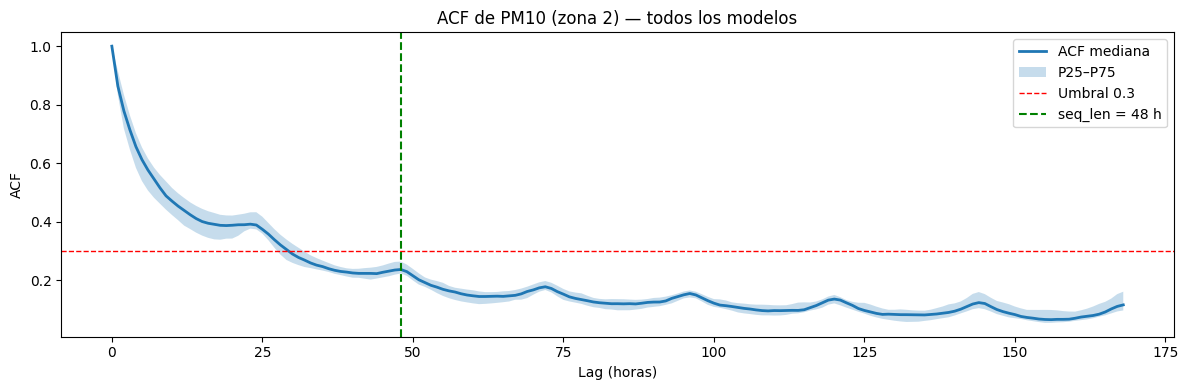

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lag_df["lag_hours"], lag_df["acf_median"], linewidth=2, label="ACF mediana")
ax.fill_between(
    lag_df["lag_hours"], lag_df["acf_p25"], lag_df["acf_p75"],
    alpha=0.25, label="P25–P75",
)
ax.axhline(ACF_THRESHOLD, color="red", linestyle="--", linewidth=1,
           label=f"Umbral {ACF_THRESHOLD}")
ax.axvline(recommendation["recommended_seq_len"], color="green", linestyle="--",
           linewidth=1.5, label=f"seq_len = {recommendation['recommended_seq_len']} h")
ax.set_xlabel("Lag (horas)")
ax.set_ylabel("ACF")
ax.set_title(f"ACF de {CONTAMINANT} (zona {ZONE}) — todos los modelos")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "acf_plot.png", dpi=120)
plt.show()

## 4. Guardar artefactos

In [8]:
lag_df.to_csv(OUTPUT_DIR / "acf_by_lag.csv", index=False)
station_df.to_csv(OUTPUT_DIR / "acf_by_station.csv", index=False)

payload = {
    "dataset": str(DATASET_PATH.as_posix()),
    "target_col": CONTAMINANT,
    "start_date": START_DATE,
    "zone": ZONE,
    **recommendation,
}
with open(OUTPUT_DIR / "seq_len_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"Guardado en: {OUTPUT_DIR.relative_to(ROOT)}")
sorted(p.name for p in OUTPUT_DIR.iterdir())

Guardado en: analysis\acf\zone_2\PM10


['acf_by_lag.csv',
 'acf_by_station.csv',
 'acf_plot.png',
 'seq_len_recommendation.json']

## 5. Result: recommended `seq_len`

In [9]:
seq_len = recommendation["recommended_seq_len"]

print("=" * 60)
print(f"  ZONE              : {ZONE}")
print(f"  CONTAMINANT       : {CONTAMINANT}")
print(f"  horizon           : {HORIZON} h")
print(f"  memory_lag (ACF)  : {recommendation['memory_lag_hours']} h")
print(f"  lower_bound       : {recommendation['lower_bound_hours']} h")
print("-" * 60)
print(f"  >>> seq_len recomendado: {seq_len} h <<<")
print("=" * 60)
print()
print("Reason:")
print(f"  {recommendation['rationale']}")
print()
print("Usar este seq_len en Informer2020 / AirFormer / GAT-Informer.")
print(f"JSON: {(OUTPUT_DIR / 'seq_len_recommendation.json').relative_to(ROOT)}")

pd.Series({
    "zone": ZONE,
    "contaminant": CONTAMINANT,
    "seq_len": seq_len,
    "horizon": HORIZON,
    "memory_lag_hours": recommendation["memory_lag_hours"],
    "acf_threshold": ACF_THRESHOLD,
    "n_stations": recommendation["n_stations"],
})

  ZONE              : 2
  CONTAMINANT       : PM10
  horizon           : 24 h
  memory_lag (ACF)  : 30 h
  lower_bound       : 30 h
------------------------------------------------------------
  >>> seq_len recomendado: 48 h <<<

Razón:
  Primer lag con ACF<0.3: 30 h; mínimo operativo max(24, 24) h; candidato elegido: 48 h

Usar este seq_len en Informer2020 / AirFormer / GAT-Informer.
JSON: analysis\acf\zone_2\PM10\seq_len_recommendation.json


zone                   2
contaminant         PM10
seq_len               48
horizon               24
memory_lag_hours      30
acf_threshold        0.3
n_stations            18
dtype: object